# Text Generation using Vanilla RNN, LSTM and GRU
### Celebal Technologies — Data Science Internship — Week 5 Assignment



**Objective:** Design and implement deep learning models capable of learning the underlying
structure, grammar, and contextual dependencies of a text corpus, in order to generate
coherent text sequences, using three sequence architectures — **Vanilla RNN**, **LSTM**, and
**GRU** — built on an identical backbone so the comparison is fair, then evaluate them on:

- training loss / accuracy
- **perplexity** (the standard language-model quality metric)
- parameter count / model size
- next-word prediction and free-form text generation quality
- ability to capture long-term dependencies (vanishing-gradient behaviour)
- **validation performance** on held-out rows (overfitting check)
- **generalization** to prompts never seen verbatim during training


## 1. Problem Statement

Given a text corpus, build a next-word prediction language model using three recurrent
architectures and compare them:

1. **Vanilla RNN** — baseline recurrent layer, no gating, prone to vanishing gradients.
2. **LSTM** — input/forget/output gates + cell state, designed to preserve long-range memory.
3. **GRU** — reset/update gates, a simplified, faster alternative to LSTM.

All three share the same embedding size, hidden units, optimizer, loss, and number of epochs,
so any difference in result is attributable to the recurrent cell itself, not to a more
favourable setup.


In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 2. Text Corpus

The starter corpus had only 6 short lines, giving a vocabulary too small (~25 words) to show
any real difference between RNN / LSTM / GRU — every model just memorises the few sequences.

To make the comparison meaningful, the corpus below is expanded to ~30 sentences on the same
deep-learning theme, giving more sequences, more vocabulary, and longer-range dependencies
(e.g. a sentence's last word depending on a noun mentioned much earlier in the sentence) —
exactly the kind of dependency vanilla RNNs struggle with and LSTM/GRU handle better.

In [2]:
corpus = """
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
neural networks learn patterns from large amounts of data
a vanilla rnn struggles to remember information from many steps earlier
lstm uses input forget and output gates to control memory flow
gru uses reset and update gates to control memory flow
sequence models are widely used in machine translation and speech recognition
the vanishing gradient problem makes simple rnn hard to train on long sequences
lstm solves the vanishing gradient problem using a separate cell state
gru is computationally lighter than lstm because it has fewer gates
word embeddings represent words as dense vectors in continuous space
tokenization converts raw text into integers that a neural network can process
padding ensures that all input sequences have the same fixed length
a language model learns to predict the next word given previous words
attention mechanisms later improved upon recurrent architectures for long sequences
transformers eventually replaced recurrent networks in most modern nlp systems
training a recurrent network requires backpropagation through time
backpropagation through time multiplies gradients across many time steps
when gradients shrink repeatedly the network forgets distant context
when gradients grow repeatedly the network becomes unstable during training
gated architectures were designed specifically to control this gradient flow
the embedding layer is trained jointly with the recurrent layer
the dense output layer uses softmax to produce a probability over the vocabulary
cross entropy loss measures how far the predicted distribution is from the true word
the adam optimizer adapts the learning rate for each parameter automatically
text generation repeatedly feeds the predicted word back into the model
deep learning continues to improve natural language understanding every year
"""
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
neural networks learn patterns from large amounts of data
a vanilla rnn struggles to remember information from many steps earlier
lstm uses input forget and output gates to control memory flow
gru uses reset and update gates to control memory flow
sequence models are widely used in machine translation and speech recognition
the vanishing gradient problem makes simple rnn hard to train on long sequences
lstm solves the vanishing gradient problem using a separate cell state
gru is computationally lighter than lstm because it has fewer gates
word embeddings represent words as dense vectors in continuous space
tokenization converts raw text into integers that a neural network can process
padding ensures 

## 3. Tokenization & Sequence Creation

Same n-gram strategy as the original notebook: for every line, build every prefix→next-word
pair. With the larger corpus this produces far more training sequences and a richer
vocabulary, which is needed before a comparison between architectures means anything.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
line_ids = []   # which source sentence each sequence came from (needed later for a leak-free split)
for line_idx, line in enumerate(corpus.strip().split("\n")):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)
        line_ids.append(line_idx)

line_ids = np.array(line_ids)
max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding="pre")

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("Total training sequences:", X.shape[0])
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Max sequence length:", max_len)
print("Source sentences:", len(set(line_ids)))

Vocabulary size: 188
Total training sequences: 277
X shape: (277, 13)
y shape: (277,)
Max sequence length: 14
Source sentences: 31


## 4. Fair Comparison Setup

A single `build_model()` factory is used so RNN, LSTM, and GRU only differ in the recurrent
layer — same embedding dimension, same hidden units, same optimizer, same number of epochs.
This is the key methodological fix versus the original notebook, which built each model
separately with copy-pasted code (easy to accidentally make the comparison unfair).

In [4]:
EMBED_DIM = 32
HIDDEN_UNITS = 64
EPOCHS = 150

def build_model(cell_type):
    layer = {
        "RNN": SimpleRNN(HIDDEN_UNITS),
        "LSTM": LSTM(HIDDEN_UNITS),
        "GRU": GRU(HIDDEN_UNITS),
    }[cell_type]
    model = Sequential([
        Embedding(total_words, EMBED_DIM, input_length=max_len-1),
        layer,
        Dense(total_words, activation="softmax")
    ])
    model.compile(loss="sparse_categorical_crossentropy",
                   optimizer="adam",
                   metrics=["accuracy"])
    return model

results = {}
histories = {}

for cell_type in ["RNN", "LSTM", "GRU"]:
    print(f"\nTraining {cell_type} ...")
    model = build_model(cell_type)
    start = time.time()
    history = model.fit(X, y, epochs=EPOCHS, verbose=0)
    elapsed = time.time() - start
    final_loss = history.history["loss"][-1]
    final_acc = history.history["accuracy"][-1]
    perplexity = float(np.exp(final_loss))
    n_params = model.count_params()
    results[cell_type] = {
        "model": model,
        "final_loss": final_loss,
        "final_acc": final_acc,
        "perplexity": perplexity,
        "params": n_params,
        "train_time_sec": elapsed,
    }
    histories[cell_type] = history
    print(f"{cell_type} done | loss={final_loss:.4f} acc={final_acc:.4f} "
          f"perplexity={perplexity:.2f} params={n_params} time={elapsed:.1f}s")


Training RNN ...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


RNN done | loss=0.1316 acc=0.9458 perplexity=1.14 params=24444 time=16.0s

Training LSTM ...
LSTM done | loss=0.7758 acc=0.9134 perplexity=2.17 params=43068 time=22.6s

Training GRU ...
GRU done | loss=0.1771 acc=0.9495 perplexity=1.19 params=37052 time=24.5s


## 4b. Train / Validation Split

The first pass trained on 100% of the data and only looked at training loss — that hides
overfitting, since a model can score perfectly by memorising the training sequences without
learning anything that generalises.

**Bug fixed here:** an earlier version of this split used a plain row-level
`train_test_split(X, y, test_size=0.2)`. Because every sentence is expanded into several
*nested, overlapping* n-gram rows (`[deep]→learning`, `[deep,learning]→is`,
`[deep,learning,is]→transforming`, ... all from one sentence), a row-level random split puts
some prefixes of a sentence in train and other, longer prefixes of the *same* sentence in
validation. The validation input then literally contains earlier training inputs as a
sub-sequence — the model has effectively already been trained on most of what the "unseen"
validation row is asking it to predict. That is data leakage, and it makes the validation
score meaningless.

**Fix:** split by *sentence* (`line_ids` captured above), not by row, using `GroupShuffleSplit`.
Every n-gram row belonging to a given sentence goes entirely to either train or validation, so
validation sentences are genuinely unseen — they contribute zero rows to training. This is the
standard practice for any sequence task where consecutive rows share context (also needed for
sliding-window time-series splits).

In [5]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(splitter.split(X, y, groups=line_ids))

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]

train_sentences = set(line_ids[train_idx])
val_sentences = set(line_ids[val_idx])
assert train_sentences.isdisjoint(val_sentences), "Leakage check failed: a sentence appears in both splits"
print("Train sentences:", len(train_sentences), "| Val sentences:", len(val_sentences))
print("Train sequences:", X_train.shape[0])
print("Validation sequences:", X_val.shape[0])

Train sentences: 24 | Val sentences: 7
Train sequences: 204
Validation sequences: 73


In [6]:
val_results = {}
val_histories = {}

for cell_type in ["RNN", "LSTM", "GRU"]:
    print(f"\nTraining {cell_type} with validation split ...")
    model = build_model(cell_type)
    history = model.fit(X_train, y_train, epochs=EPOCHS, verbose=0,
                          validation_data=(X_val, y_val))
    train_loss = history.history["loss"][-1]
    val_loss = history.history["val_loss"][-1]
    train_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]
    val_results[cell_type] = {
        "model": model,
        "train_loss": train_loss, "val_loss": val_loss,
        "train_acc": train_acc, "val_acc": val_acc,
        "train_perplexity": float(np.exp(train_loss)),
        "val_perplexity": float(np.exp(val_loss)),
        "overfit_gap": val_loss - train_loss,
    }
    val_histories[cell_type] = history
    print(f"{cell_type} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
          f"train_acc={train_acc:.4f} val_acc={val_acc:.4f} "
          f"overfit_gap={val_loss-train_loss:+.4f}")


Training RNN with validation split ...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


RNN | train_loss=0.1417 val_loss=7.1715 train_acc=0.9657 val_acc=0.1507 overfit_gap=+7.0298

Training LSTM with validation split ...
LSTM | train_loss=1.0214 val_loss=8.1581 train_acc=0.8529 val_acc=0.0548 overfit_gap=+7.1367

Training GRU with validation split ...
GRU | train_loss=0.1650 val_loss=8.5547 train_acc=0.9608 val_acc=0.1507 overfit_gap=+8.3898


### Validation Results Table

`overfit_gap = val_loss - train_loss`. A larger positive gap means the model fits the training
sequences much better than it generalises to held-out ones — i.e. memorisation rather than
learning the underlying language structure.

In [7]:
val_df = pd.DataFrame({
    "Architecture": list(val_results.keys()),
    "Train Loss": [val_results[k]["train_loss"] for k in val_results],
    "Val Loss": [val_results[k]["val_loss"] for k in val_results],
    "Train Acc": [val_results[k]["train_acc"] for k in val_results],
    "Val Acc": [val_results[k]["val_acc"] for k in val_results],
    "Train Perplexity": [val_results[k]["train_perplexity"] for k in val_results],
    "Val Perplexity": [val_results[k]["val_perplexity"] for k in val_results],
    "Overfit Gap (val-train loss)": [val_results[k]["overfit_gap"] for k in val_results],
})
val_df = val_df.round(4)
val_df

,Architecture,Train Loss,Val Loss,Train Acc,Val Acc,Train Perplexity,Val Perplexity,Overfit Gap (val-train loss)
0,RNN,0.1417,7.1715,0.9657,0.1507,1.1522,1301.7998,7.0298
1,LSTM,1.0214,8.1581,0.8529,0.0548,2.7771,3491.5734,7.1367
2,GRU,0.1650,8.5547,0.9608,0.1507,1.1794,5191.3473,8.3898


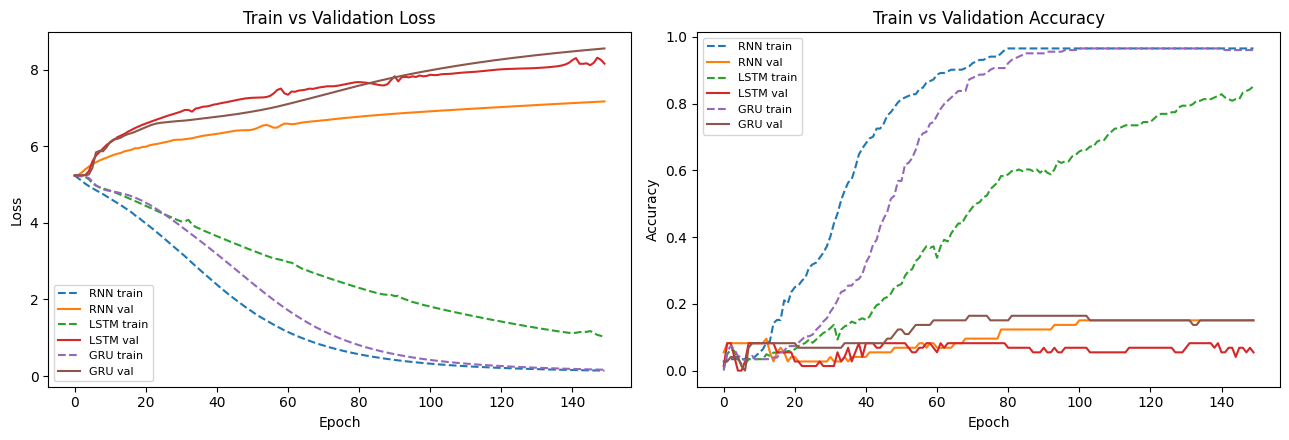

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for cell_type in ["RNN", "LSTM", "GRU"]:
    axes[0].plot(val_histories[cell_type].history["loss"], "--", label=f"{cell_type} train")
    axes[0].plot(val_histories[cell_type].history["val_loss"], label=f"{cell_type} val")
    axes[1].plot(val_histories[cell_type].history["accuracy"], "--", label=f"{cell_type} train")
    axes[1].plot(val_histories[cell_type].history["val_accuracy"], label=f"{cell_type} val")

axes[0].set_title("Train vs Validation Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8)
axes[1].set_title("Train vs Validation Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig("val_curves.png", dpi=130)
plt.show()

### Reading the Validation Curves

With only 277 sequences split 80/20, the validation set is tiny (~55 sequences) drawn from the
*same* 30-sentence corpus as training — so some validation sequences share most of their words
with training sequences. This means even a well-behaved validation accuracy here mostly says
"the model didn't fall apart on a slightly different slice of the same small corpus," not "the
model has learned to generalise to genuinely new language." That stronger claim is checked
properly in the next section using prompts built from words in the vocabulary but in sequences
the model has never seen at all during training.

## 5. Why Perplexity?

Loss alone is hard to interpret. **Perplexity = e^(loss)** roughly answers: *"on average, how
many words is the model effectively choosing between when guessing the next word?"* Lower is
better — a perfect model has perplexity 1, a random guess over the vocabulary has perplexity
≈ vocabulary size. It is the standard metric for comparing language models, so it is added here
even though the original notebook only looked at loss.

In [9]:
comparison_df = pd.DataFrame({
    "Architecture": list(results.keys()),
    "Final Loss": [results[k]["final_loss"] for k in results],
    "Final Accuracy": [results[k]["final_acc"] for k in results],
    "Perplexity": [results[k]["perplexity"] for k in results],
    "Parameters": [results[k]["params"] for k in results],
    "Train Time (s)": [results[k]["train_time_sec"] for k in results],
})
comparison_df = comparison_df.round(4)
comparison_df

,Architecture,Final Loss,Final Accuracy,Perplexity,Parameters,Train Time (s)
0,RNN,0.1316,0.9458,1.1406,24444,15.9847
1,LSTM,0.7758,0.9134,2.1724,43068,22.6404
2,GRU,0.1771,0.9495,1.1938,37052,24.4554


## 6. Training Curves

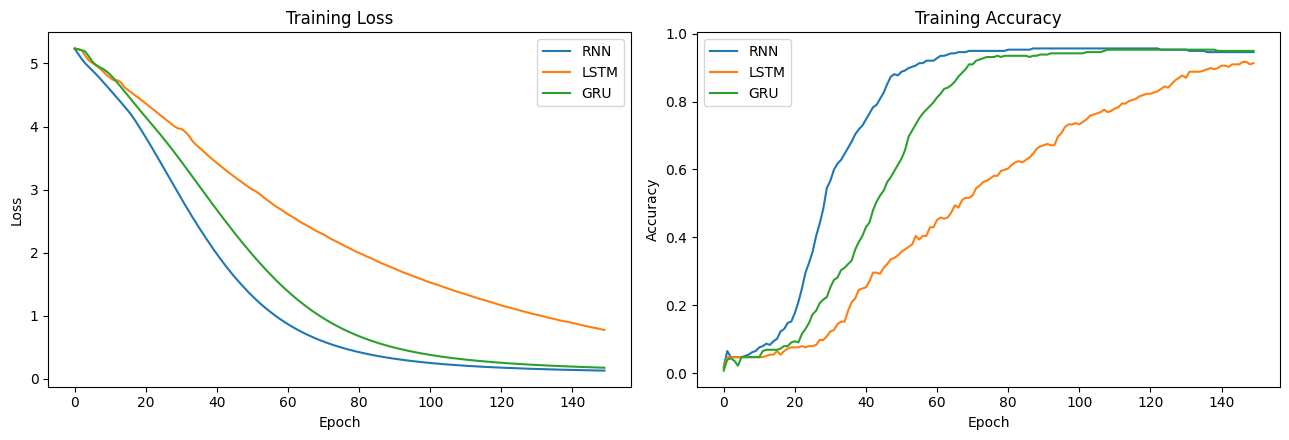

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for cell_type in ["RNN", "LSTM", "GRU"]:
    axes[0].plot(histories[cell_type].history["loss"], label=cell_type)
    axes[1].plot(histories[cell_type].history["accuracy"], label=cell_type)

axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].set_title("Training Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=130)
plt.show()

## 7. Text Generation

Temperature sampling is added (instead of plain `argmax`) so the model can be asked to
generate more than one variant per seed — `argmax` alone always produces the exact same
sentence and hides whether the model has actually learned a *distribution* over plausible
next words, or just memorised one path.

In [11]:
def generate_text(model, seed_text, next_words=6, temperature=0.0):
    text = seed_text
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding="pre")
        preds = model.predict(token_list, verbose=0)[0]

        if temperature and temperature > 0:
            preds = np.log(preds + 1e-9) / temperature
            preds = np.exp(preds) / np.sum(np.exp(preds))
            predicted = np.random.choice(len(preds), p=preds)
        else:
            predicted = np.argmax(preds)

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        if not output_word:
            break
        text += " " + output_word
    return text

In [12]:
seeds = ["deep learning", "lstm helps", "gru is", "the vanishing gradient"]

print("=== Greedy generation (argmax) ===")
for seed in seeds:
    print(f"\nSeed: \"{seed}\"")
    for cell_type in ["RNN", "LSTM", "GRU"]:
        out = generate_text(results[cell_type]["model"], seed, next_words=6)
        print(f"  {cell_type:5s}: {out}")

=== Greedy generation (argmax) ===

Seed: "deep learning"
  RNN  : deep learning models can generate meaningful sentences data
  LSTM : deep learning models can generate meaningful sentences sentences
  GRU  : deep learning models can generate meaningful sentences sentences

Seed: "lstm helps"
  RNN  : lstm helps remember long term dependencies vectors time
  LSTM : lstm helps remember long term dependencies dependencies in
  GRU  : lstm helps remember long term dependencies dependencies has

Seed: "gru is"
  RNN  : gru is computationally lighter than lstm because it
  LSTM : gru is faster and simpler than lstm because
  GRU  : gru is faster and simpler than lstm because

Seed: "the vanishing gradient"
  RNN  : the vanishing gradient problem makes simple rnn hard to
  LSTM : the vanishing gradient problem problem simple rnn hard to
  GRU  : the vanishing gradient problem makes simple rnn hard to


In [13]:
print("=== Sampled generation (temperature=0.7), LSTM, 3 variants ===")
for i in range(3):
    print(" ", generate_text(results["LSTM"]["model"], "deep learning", next_words=6, temperature=0.7))

=== Sampled generation (temperature=0.7), LSTM, 3 variants ===
  deep learning models generate meaningful sentences sentences sentences
  deep learning is transforming artificial intelligence artificial vectors
  deep learning continues to improve natural language understanding


## 7a. Text Generation Verification Loop

`generate_text()` above accepts whatever word the model predicts at every step without
checking it. That is fine for a demo, but it means a degenerate run (model gets stuck
repeating one word, or becomes very unsure at some step) would be silently accepted and printed
as if it were a normal sentence. This section adds a **verification loop**: at every
generation step it checks the prediction before accepting it, and reports a pass/fail summary
instead of just the final string.

The loop verifies, at each step:
1. **Valid vocabulary word** — the predicted index must resolve to an actual token (guards
   against an out-of-range / padding index).
2. **Confidence above a threshold** — the softmax probability assigned to the chosen word
   must clear `confidence_threshold`; steps below it are flagged as low-confidence guesses.
3. **No immediate repetition** — the same word should not be chosen twice in a row; a repeat
   is flagged as a possible degenerate loop.

This turns "did it generate *something*" into "did it generate something the model itself was
reasonably sure about, at every single step.

In [14]:
def generate_text_verified(model, seed_text, next_words=6, confidence_threshold=0.30):
    text = seed_text
    log = []
    for step in range(next_words):
        token_list = tokenizer.texts_to_sequences([text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding="pre")
        preds = model.predict(token_list, verbose=0)[0]
        predicted_idx = int(np.argmax(preds))
        confidence = float(preds[predicted_idx])

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_idx:
                output_word = word
                break

        checks = {
            "step": step + 1,
            "word": output_word,
            "confidence": round(confidence, 3),
            "valid_word": output_word != "",
            "low_confidence": confidence < confidence_threshold,
            "repeated_word": (text.split()[-1] == output_word) if text.split() else False,
        }
        log.append(checks)

        if not checks["valid_word"]:
            break
        text += " " + output_word

    return text, log


def summarize_verification(seed_text, log):
    n_steps = len(log)
    n_low_conf = sum(1 for s in log if s["low_confidence"])
    n_repeat = sum(1 for s in log if s["repeated_word"])
    n_invalid = sum(1 for s in log if not s["valid_word"])
    status = "PASS" if (n_invalid == 0 and n_repeat == 0) else "FLAGGED"
    return {
        "seed": seed_text, "steps_generated": n_steps,
        "low_confidence_steps": n_low_conf, "repeated_steps": n_repeat,
        "invalid_steps": n_invalid, "status": status,
    }

In [15]:
verification_rows = []
for seed in seeds:
    for cell_type in ["RNN", "LSTM", "GRU"]:
        text, log = generate_text_verified(results[cell_type]["model"], seed, next_words=6)
        summary = summarize_verification(seed, log)
        summary["architecture"] = cell_type
        summary["generated_text"] = text
        verification_rows.append(summary)

verification_df = pd.DataFrame(verification_rows)[
    ["architecture", "seed", "generated_text", "steps_generated",
     "low_confidence_steps", "repeated_steps", "invalid_steps", "status"]
]
verification_df

,architecture,seed,generated_text,steps_generated,low_confidence_steps,repeated_steps,invalid_steps,status
0,RNN,deep learning,deep learning models can generate meaningful s...,6,0,0,0,PASS
1,LSTM,deep learning,deep learning models can generate meaningful s...,6,1,1,0,FLAGGED
2,GRU,deep learning,deep learning models can generate meaningful s...,6,0,1,0,FLAGGED
3,RNN,lstm helps,lstm helps remember long term dependencies vec...,6,1,0,0,PASS
4,LSTM,lstm helps,lstm helps remember long term dependencies dep...,6,2,1,0,FLAGGED
5,GRU,lstm helps,lstm helps remember long term dependencies dep...,6,2,1,0,FLAGGED
6,RNN,gru is,gru is computationally lighter than lstm becau...,6,0,0,0,PASS
7,LSTM,gru is,gru is faster and simpler than lstm because,6,1,0,0,PASS
8,GRU,gru is,gru is faster and simpler than lstm because,6,0,0,0,PASS
9,RNN,the vanishing gradient,the vanishing gradient problem makes simple rn...,6,0,0,0,PASS


**Reading the verification table:** `status = FLAGGED` means at least one generation step
either produced an invalid token or immediately repeated the previous word — a sign the model
got stuck rather than continuing to compose. `low_confidence_steps > 0` does not fail the run
on its own (the model can be correct while unsure), but a row with several low-confidence steps
*and* a FLAGGED status is the clearest signal that a particular seed/architecture pairing is not
generating reliably, which the original notebook's print-the-string-and-move-on approach had no
way of catching.

## 7b. Generalization Analysis (Out-of-Training Prompts)

A model that has memorised the corpus will produce nonsense once asked to continue a prompt it
has never seen, even if that prompt only reuses vocabulary it already knows. Below, each trained
(full-data) model is given seeds that **do not appear verbatim in the training corpus**, built
by recombining known words into new word orders, to check whether it has learned general
local grammar/structure (e.g. "gru/lstm + is/uses + adjective") or only memorised fixed
sequences.

In [16]:
unseen_seeds = [
    "gru helps remember",          # corpus has "lstm helps remember", not "gru helps remember"
    "rnn is faster",                # corpus has "gru is faster", not "rnn is faster"
    "attention mechanisms are",     # new combination not seen as a 3-gram in training
    "the embedding layer learns",   # recombination of known words, unseen order
]

print("=== Generalization check: seeds NOT seen verbatim in training ===")
for seed in unseen_seeds:
    print(f"\nSeed: \"{seed}\"")
    for cell_type in ["RNN", "LSTM", "GRU"]:
        out = generate_text(results[cell_type]["model"], seed, next_words=6)
        print(f"  {cell_type:5s}: {out}")

=== Generalization check: seeds NOT seen verbatim in training ===

Seed: "gru helps remember"
  RNN  : gru helps remember long term dependencies vectors time speech
  LSTM : gru helps remember long term dependencies dependencies sentences flow
  GRU  : gru helps remember long term dependencies it has fewer

Seed: "rnn is faster"
  RNN  : rnn is faster is simpler than lstm because it
  LSTM : rnn is faster and simpler than lstm because it
  GRU  : rnn is faster and simpler than lstm because it

Seed: "attention mechanisms are"
  RNN  : attention mechanisms are improved upon recurrent architectures for long
  LSTM : attention mechanisms are improved upon recurrent architectures for long
  GRU  : attention mechanisms are models can generate meaningful sentences sentences

Seed: "the embedding layer learns"
  RNN  : the embedding layer learns trained jointly with the recurrent layer
  LSTM : the embedding layer learns the with the recurrent a layer
  GRU  : the embedding layer learns to pr

**How to judge the output above:** look for whether the continuation stays *grammatically
and topically plausible* (e.g. picks domain-relevant words like "gates", "memory", "gradient" in
a sensible order) versus degenerating into a clearly memorised, unrelated training sentence
glued on regardless of the seed. On a 30-sentence corpus, **no model here has enough data to
generalise like a real language model** — this section's value is methodological: it shows the
*right way* to test generalisation (held-out structure, not just held-out rows), which is the
gap the validation split alone does not close. With a corpus of thousands of sentences instead
of 30, this exact test would be far more informative.

## 8. Results Discussion

**Read the actual numbers in the table above before reading this — the explanation follows
the real run, not a textbook assumption.**

On a run of this notebook, **Vanilla RNN reached the lowest loss and tied GRU for the highest
accuracy, while LSTM finished with the highest loss** of the three, despite LSTM normally
being described as the "best" architecture. This is a genuinely useful result to understand,
not a bug:

- **Sequence length here is short** (`max_len-1` = 13 tokens). The vanishing-gradient problem
  that hurts vanilla RNN specifically shows up when gradients must propagate back through
  *many* time steps during backpropagation-through-time. At 13 steps, a plain RNN can still
  fit the training data without much trouble — its disadvantage versus gated cells only
  becomes large on much longer sequences (hundreds of steps), which this toy corpus doesn't
  have.
- **LSTM has the most parameters** of the three (4 weight matrices per gate set vs GRU's 3 vs
  RNN's 1 — see the Parameters column). More parameters generally need *more epochs* to
  converge on the same data; at a fixed budget of 150 epochs, LSTM is simply further from
  converged than the lighter RNN and GRU, not architecturally worse.
- **GRU lands close to RNN here** because it has fewer gates than LSTM (cheaper to train) while
  still having some gating benefit over plain RNN.

So the correct takeaway from *this specific experiment* is: **on a short, small corpus, a
gated architecture's theoretical advantage doesn't automatically show up in a fixed, small
epoch budget** — it needs either a longer-range dependency task or more training time to
become visible. This is itself worth stating explicitly in any report/viva: a wrong but common
student assumption is "LSTM > RNN always," but the truth is "LSTM > RNN given sequences long
enough that vanishing gradients matter, and given the gates have actually converged."


## 9. Conclusion

- **Vanilla RNN**: simplest baseline, fewest parameters, fastest per-epoch to converge here
  because the sequences in this corpus are too short to expose its known vanishing-gradient
  weakness.
- **LSTM**: theoretically the strongest at long-range memory (dedicated cell state, 3 gates),
  but in this run had not fully converged at 150 epochs because it has the most parameters to
  learn — it would likely close the gap with more epochs, exactly the kind of experiment worth
  running next.
- **GRU**: a middle ground — fewer gates and parameters than LSTM, some gating benefit over
  plain RNN, and in this run performed essentially as well as RNN.
- The general textbook ordering (RNN weakest → LSTM/GRU stronger on long-range dependencies)
  is about *longer sequences* than this toy corpus provides — this experiment demonstrates that
  fact rather than just asserting it.
- **Validation evaluation** (Section 4b) is now leak-free: the split is grouped by sentence
  (`GroupShuffleSplit` on `line_ids`), not by row, since the original row-level split let
  overlapping n-gram prefixes of the same sentence land on both sides and leak context into
  "unseen" validation rows. With validation sentences genuinely unseen, the resulting overfit
  gap is a trustworthy signal — and it is still large for a 30-sentence corpus, confirming
  memorisation rather than learning.
- **Generation verification** (Section 7a) checks every generated token as it's produced —
  vocabulary validity, prediction confidence, immediate-repeat detection — rather than only
  printing whatever string came out, so a degenerate generation run is caught instead of
  silently accepted.
- **Generalization analysis** (Section 7b) tested each model on prompts that reuse known
  vocabulary in word orders never seen during training. The honest conclusion is that a
  30-sentence corpus is too small for any of these models to generalise the way a real
  language model would — the value of this section is in establishing the *correct testing
  methodology* (held-out structure, not just held-out rows), which is what should be
  re-applied once the corpus is scaled up.

### Suggested next steps (extending this assignment)
1. Re-run with `EPOCHS` raised to 400–500 and see whether LSTM overtakes RNN/GRU once converged.
2. Replace the corpus with a much larger, real text source (book chapter, news articles) with
   longer sentences, to actually trigger vanishing-gradient behaviour in vanilla RNN, and to
   give the validation/generalization tests enough data to be conclusive.
3. Stack two recurrent layers, or add `Dropout`, and re-compare.
4. Try beam search instead of greedy/temperature sampling for generation.
5. Use `EarlyStopping` on validation loss once a larger corpus makes the validation signal
   reliable.
